In [7]:
import os
import os.path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
datadir = "data"
data = os.path.join(datadir, "adult.data")
df = pd.read_csv(data)
df.columns = ["age", "workclass", "fnlwgt", "education", "education-num", 
              "marital-status", "occupation", "relationship", "race", "sex", 
              "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]

In [3]:
def avg_equiv_class_size_metric(data, qids, k):
    """
    Return the average sizes of the equivalence classes with respect to the QID set.
    Input:
        data: The input k-anonymized dataframe
        qids: the set of QIDs
    """
    eq_classes = data.groupby(list(qids)).size()
    return eq_classes.mean() / k


def discernability_metrics(data, qids):
    """
    Return the discernability score of the dataset with respect to the QID set.
    The discernability is calculated by assigning the penalty to each tuple depending 
    on the how many tuples are indistinguishable from it.
    Input:
        data (pandas.DataFrame): The input k-anonymized dataframe
        qids (set): the set of QIDs
    """
    eq_classes = data.groupby(list(qids)).size()
    return (eq_classes ** 2).sum()


def classification_metrics(data, qids, sensitive_attr):
    """
    Return the classification metric score of the data with respect to the QID set,
    where we assign a penalty to each tuple t. If t's sensitive attribute matches 
    the majority sensitive attribute, the penalty = 0. Otherwise, penalty = size of the equivalence class.
    Input:
        data (pandas.DataFrame): The input k-anonymized dataframe
        qids (set): the set of QIDs
    """
    penalties = 0
    for _, group in data.groupby(list(qids)):
        # class_size = len(group)
        majority = group[sensitive_attr].value_counts().idxmax()
        mismatches = group[group[sensitive_attr] != majority]
        penalties += len(mismatches)
    return penalties / len(data)

In [10]:
# ----------------------------
# AGE
# ----------------------------
def generalize_age(age, level=3):
    if level == 2:  # 5-year bins
        return f"{(age // 5) * 5}-{(age // 5) * 5 + 4}"
    elif level == 3:  # 10-year bins
        return f"{(age // 10) * 10}-{(age // 10) * 10 + 9}"
    elif level == 4:  # broad groups
        if age <= 24: return "Youth"
        elif age <= 44: return "Young Adult"
        elif age <= 64: return "Middle-aged"
        else: return "Senior"
    return age  # raw

# ----------------------------
# EDUCATION
# ----------------------------
def generalize_education(ed, level=3):
    ed = ed.strip()
    if level == 2:
        primary = ['Preschool','1st-4th','5th-6th','7th-8th']
        secondary = ['9th','10th','11th','12th','HS-grad']
        postsecondary = ['Some-college','Assoc-acdm','Assoc-voc']
        tertiary = ['Bachelors','Masters','Doctorate','Prof-school']
        if ed in primary: return 'Primary'
        if ed in secondary: return 'Secondary'
        if ed in postsecondary: return 'Postsecondary'
        if ed in tertiary: return 'Tertiary'
    elif level == 3:
        if ed in ['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th','HS-grad']:
            return 'Low'
        if ed in ['Some-college','Assoc-acdm','Assoc-voc']:
            return 'Medium'
        if ed in ['Bachelors','Masters','Doctorate','Prof-school']:
            return 'High'
    elif level == 4:
        if ed in ['Bachelors','Masters','Doctorate','Prof-school']:
            return 'High'
        return 'Low'
    return ed

# ----------------------------
# HOURS-PER-WEEK
# ----------------------------
def generalize_hours(h, level=3):
    if level == 2:
        if h < 20: return "0–19"
        elif h < 40: return "20–39"
        elif h < 60: return "40–59"
        else: return "60+"
    elif level == 3:
        if h < 35: return "Part-time"
        elif h < 50: return "Full-time"
        else: return "Overtime"
    elif level == 4:
        return "Standard" if h == 40 else "Nonstandard"
    return h

# ----------------------------
# NATIVE-COUNTRY
# ----------------------------
def generalize_country(c, level=3):
    c = c.strip()
    if level == 2:
        NA = ['United-States','Canada','Puerto-Rico','Outlying-US(Guam-USVI-etc)','Honduras','Mexico','Cuba','Jamaica','Trinadad&Tobago']
        EU = ['England','Germany','Italy','Poland','France','Yugoslavia','Scotland','Greece','Ireland','Hungary','Holand-Netherlands']
        AS = ['India','Iran','Philippines','Cambodia','Thailand','Laos','Taiwan','China','Japan','Vietnam','Hong']
        LATAM = ['Columbia','Ecuador','Haiti','Dominican-Republic','El-Salvador','Guatemala','Nicaragua','Peru','South']
        if c in NA: return "North America"
        if c in EU: return "Europe"
        if c in AS: return "Asia"
        if c in LATAM: return "Latin America"
        if c == '?': return "Unknown"
        return "Other"
    elif level == 3:
        if c == "United-States": return "US"
        if c == "?": return "Unknown"
        return "Non-US"
    elif level == 4:
        return "Domestic" if c == "United-States" else "Foreign/Unknown"
    return c


# ----------------------------
# MARITAL-STATUS
# ----------------------------
def generalize_marital(ms, level=3):
    ms = ms.strip()
    if level == 2:
        if "Married" in ms:
            return "Married"
        else:
            return "Not married"
    elif level == 3:
        if "Married" in ms:
            return "With partner"
        else:
            return "Without partner"
    return ms  # raw

# ----------------------------
# RELATIONSHIP
# ----------------------------
def generalize_relationship(r, level=3):
    r = r.strip()
    if level == 2:
        if r in ['Husband','Wife','Own-child','Other-relative']:
            return "In-family"
        else:
            return "Not-in-family"
    elif level == 3:
        if r in ['Husband','Wife','Own-child','Other-relative']:
            return "With family"
        else:
            return "Without family"
    return r

# ----------------------------
# RACE
# ----------------------------
def generalize_race(r, level=3):
    r = r.strip()
    if level == 2:
        if r == "White": return "White"
        if r == "Black": return "Black"
        if r == "Asian-Pac-Islander": return "Asian"
        return "Other"
    elif level == 3:
        if r == "White": return "Majority"
        return "Minority"
    return r


In [16]:
def apply_generalization(df, levels):
    """Apply manual generalization to attributes based on levels dict."""
    df = df.copy()
    df["age"] = df["age"].apply(lambda x: generalize_age(x, levels.get("age", 1)))
    df["education"] = df["education"].apply(lambda x: generalize_education(x, levels.get("education", 1)))
    df["hours-per-week"] = df["hours-per-week"].apply(lambda x: generalize_hours(x, levels.get("hours", 1)))
    df["native-country"] = df["native-country"].apply(lambda x: generalize_country(x, levels.get("country", 1)))
    df["marital-status"] = df["marital-status"].apply(lambda x: generalize_marital(x, levels.get("marital", 1)))
    df["relationship"] = df["relationship"].apply(lambda x: generalize_relationship(x, levels.get("relationship", 1)))
    df["race"] = df["race"].apply(lambda x: generalize_race(x, levels.get("race", 1)))
    return df

def run_k_anonymization(data, k, levels, qids, sensitive_attr, output_csv="generalized.csv"):
    """
    Apply k-anonymization using ONLY manual generalization (no Mondrian).
    Suppresses equivalence classes with fewer than k records.
    """
    # 1. Drop fnlwgt if present
    if "fnlwgt" in data.columns:
        data = data.drop(columns=["fnlwgt"])

    # 2. Apply manual generalization
    gen_data = apply_generalization(data, levels)

    # 3. Enforce k-anonymity: suppress rare equivalence classes
    eq_sizes = gen_data.groupby(qids).size()
    small_classes = eq_sizes[eq_sizes < k].index  # equivalence class keys

    # Make a copy for suppression
    gen_data = gen_data.copy()
    for idx in small_classes:
        mask = (gen_data[qids] == pd.Series(idx, index=qids)).all(axis=1)
        gen_data.loc[mask, qids] = "SUPPRESSED"

    # 4. Save to CSV
    gen_data.to_csv(output_csv, index=False)

    # 5. Compute utility metrics
    avg_eq = avg_equiv_class_size_metric(gen_data, qids, k)
    discern = discernability_metrics(gen_data, qids)
    classif = classification_metrics(gen_data, qids, sensitive_attr)

    return gen_data, {
        "avg_eq_size": avg_eq,
        "discernability": discern,
        "classification": classif
    }


In [18]:
def compare_k_levels(data, k_values, levels, qids, sensitive_attr):
    """
    Run anonymization for multiple k values and compare utility.
    Plots all metrics on a single normalized plot.
    """
    results = []
    
    for k in k_values:
        gen_data, metrics = run_k_anonymization(
            data, k, levels, qids, sensitive_attr,
            output_csv=f"generalized_k{k}.csv"
        )
        metrics["k"] = k
        results.append(metrics)

    # Convert to DataFrame for plotting
    results_df = pd.DataFrame(results)

    # Normalize metrics for comparison (0–1 scale)
    metrics_to_plot = ["avg_eq_size", "discernability", "classification"]
    normalized = results_df.copy()
    for col in metrics_to_plot:
        normalized[col] = (results_df[col] - results_df[col].min()) / (results_df[col].max() - results_df[col].min())

    # Plot all three metrics on one figure
    plt.figure(figsize=(8, 6))
    for col in metrics_to_plot:
        plt.plot(results_df["k"], normalized[col], marker="o", label=col)

    plt.xlabel("k (Anonymization Level)")
    plt.ylabel("Normalized Metric Value")
    plt.title("Privacy–Utility Tradeoff Across k-levels")
    plt.legend()
    plt.grid(True)
    plt.show()

    return results_df

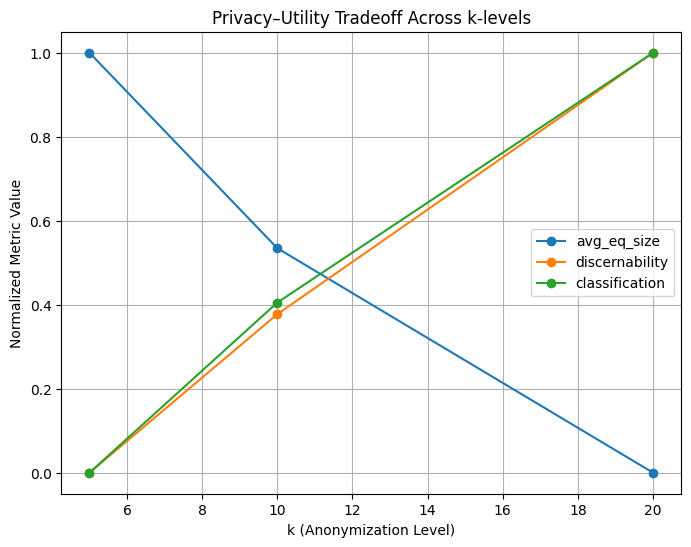

   avg_eq_size  discernability  classification   k
0    15.004608        16827846        0.173464   5
1    12.669261        21842154        0.174908  10
2     9.987730        30110526        0.177027  20


In [19]:
QIDs = ["age", "education", "marital-status",
        "relationship", "race", "sex", "native-country"]
sensitive_attr = "income"
levels = {
    "age": 3,
    "education": 2,
    "hours": 3,
    "country": 2,
    "marital": 2,
    "relationship": 2,
    "race": 2
}
results_df = compare_k_levels(df, k_values=[5, 10, 20], levels=levels, qids=QIDs, sensitive_attr=sensitive_attr)
print(results_df)